# Randon Forest Classifer

## Concepts:
1. Random Forest Classifer 
    * It is a combination of n amount of decision trees. For Regression, you take the average of decision tree's output. For Classification, you take the class with the highest amount of value.
    * Decision Trees are often overfit and have high variance. Random Forest fix this issues, by training and using a n amount of decision trees.
2. Permutation Feature Importance(PFI)
    * A metric to decide how important a feature is in determining a model's output.
    * How it works:
        * Create a model, trained on the dataset with on dataset. Find the baselin score of that model on the training dataset.
        * Take a feature, and move swao and rearrange the order of data in that column.
        * Create an another model, trained on the dataset with this permutated dataset. Find the  score of that model on the permutated dataset
        * The difference between baseline score and permuated model score is the "importance". A Bigger Importance, means the more important the feature is.
    * Main Drawbacks:
        * PFI only works on one feature at a time. This means if there are features that are highly corrlated, and important to the model, PFI will fail to notice it. The other features that have a correlation with the feature being targeted, will cover and hide the importantce of the chosen feature, as the other features also are encryptying the same signal.
        * This means PFI struggles to be a good method on datasets with values that highly correlated. 

🚩
Deliverable: Train a RandomForestClassifier with oob_score=True. Compare OOB accuracy to 5-fold CV accuracy. Plot both impurity-based and permutation importances side by side — note any features that rank very differently between the two methods and explain why.

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
y = (y > 0).astype(int)

In [2]:
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, test_size=0.2)
len(X_train), len(X_test)

(242, 61)

In [4]:
model = RandomForestClassifier(n_estimators=200, oob_score=True,)
params = {"max_features": [7,8,9,10,11], "max_depth": [3,5,7,9]}
gcv = GridSearchCV(model, param_grid=params, cv=5, scoring='accuracy')


gcv.fit(X_train, y_train)
obb = gcv.best_estimator_.oob_score_
print(f"OBB Score: {obb}")

d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
d:\User\Vakeesan's Pc\Download\DS Projects - Summer 2026\ML Learning Delivarbles\venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
d:\User\Vakee

OBB Score: 0.8388429752066116


In [6]:
model = gcv.best_estimator_

In [7]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.8360655737704918

In [8]:
perm = permutation_importance(model, X_test, y_test, n_repeats=10)

In [9]:
model.feature_importances_

array([0.02517443, 0.03629566, 0.22020745, 0.02501424, 0.03146321,
       0.00078411, 0.00203725, 0.07147211, 0.0535771 , 0.08326924,
       0.03872522, 0.2557024 , 0.1562776 ])

In [10]:
perm['importances_mean']

array([-0.00327869,  0.00491803,  0.03606557, -0.00655738,  0.        ,
        0.        ,  0.        , -0.00163934,  0.01311475,  0.02295082,
        0.00819672,  0.01147541,  0.07868852])

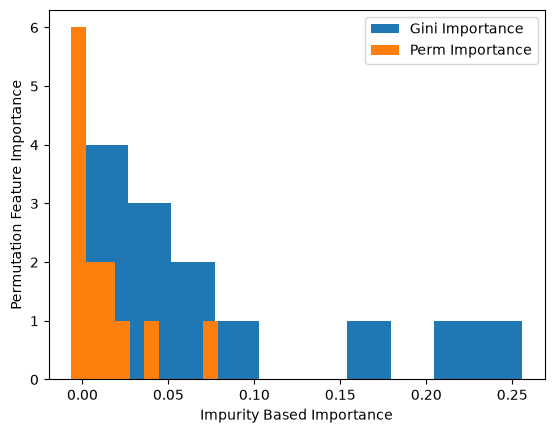

In [19]:
plt.hist(model.feature_importances_, label="Gini Importance")
plt.hist(perm['importances_mean'], label="Perm Importance")
plt.xlabel("Impurity Based Importance")
plt.ylabel("Permutation Feature Importance")
plt.legend()
plt.show()

In [34]:
X['y'] = y

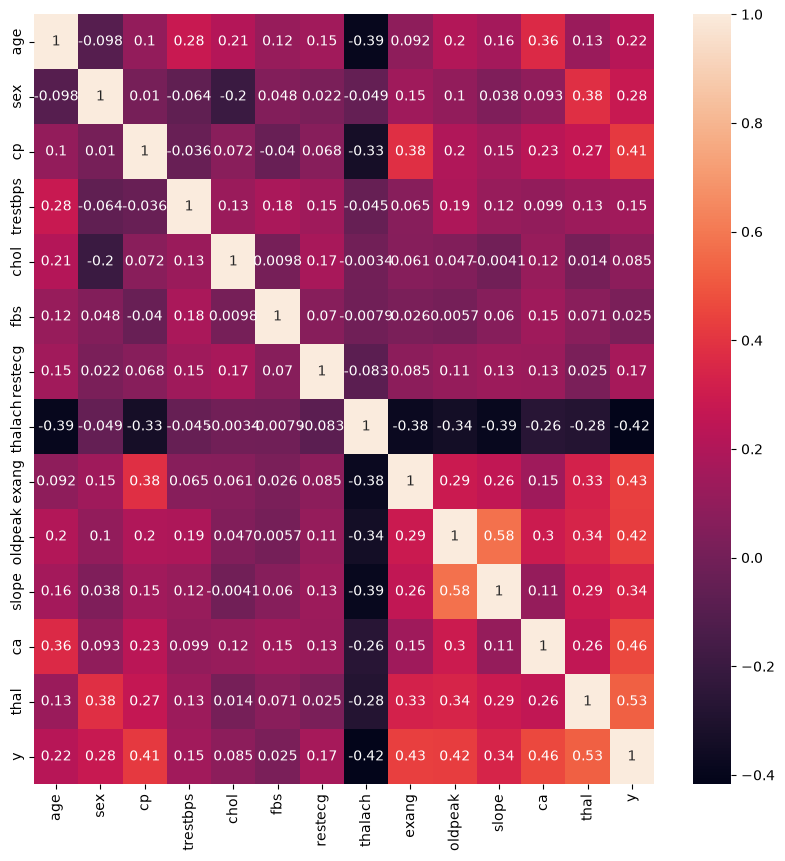

In [38]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(X.corr(), annot=True)
plt.show()